# Exercise 4.A Introduction to Linear Regression

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Lab 1
### Running a sample script

In [11]:
# Sample dataset: hours studied vs. exam score
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'exam_score':    [52, 55, 60, 65, 68, 72, 75, 80, 85, 90]
}
df = pd.DataFrame(data)

# Step 1: Define features (X) and target (y)
X = df[['hours_studied']]   # 2D: double brackets give a DataFrame, not a Series
y = df['exam_score']        # 1D: single brackets give a Series

# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Create the model and fit it to training data
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


### Working through the sample script

In a code cell, print the slope (model.coef_[0]) and intercept (model.intercept_) of the
fitted model, using the following code:
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')

In [14]:
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}')
print(f'intercept:{model.intercept_:.2f}')



Slope (coefficient): 4.10
intercept:47.68


n another code cell, add the following prediction code:
y_pred = model.predict(X_test)

In [15]:
y_pred = model.predict(X_test)

In [16]:
print('Actual scores: ', list(y_test))
print('Predicted scores:', list(y_pred.round(1)))

Actual scores:  [85, 55]
Predicted scores: [np.float64(84.6), np.float64(55.9)]


In another code cell, add the following evaluation code to find how much of the
variation in your target variable is explained by your model:
r_squared = model.score(X_test, y_test)
print(f'R² score: {r_squared:.3f}')

In [17]:
r_squared = model.score(X_test, y_test)
print(f'R² score: {r_squared:.3f}')

R² score: 0.998


# what does the R² score
# mean, and what does it tell you about how well this model fits the data?

 The R2 score measures how well the linear regression model fits in data.
 A value close to 1 means the model fits the data very well.
 A value close to 0 means the model does not explain the data well.    

In another code cell, add the following code to visualize the regression line

C:\Users\luiso\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


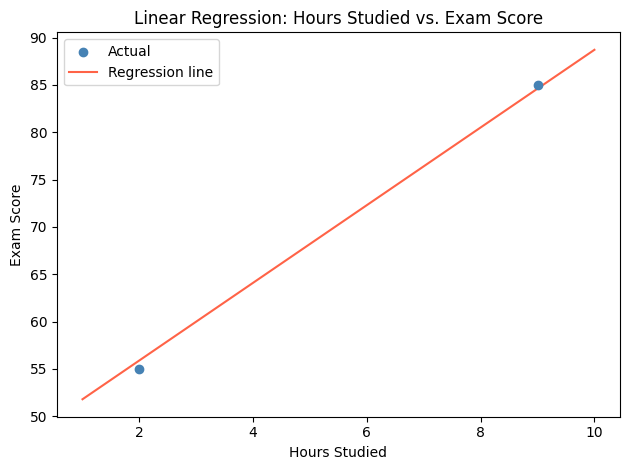

In [18]:
# Scatter plot: actual test data points
plt.scatter(X_test, y_test, color='steelblue', label='Actual',
zorder=3)
# Line: model predictions across the full range of X
x_range = np.linspace(
X['hours_studied'].min(),
X['hours_studied'].max(),
100).reshape(-1, 1)
y_line = model.predict(x_range)
plt.plot(x_range, y_line, color='tomato', label='Regression line')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Hours Studied vs. Exam Score')
plt.legend()
plt.tight_layout()
plt.show()

the blue dots follow the regression line closely
this shows a strong positive relationship between hours studied and exam scores. As study hours increas, exam scores also increase

## Lab 2
### Building your own model

In a code cell, create a DataFrame named df_ads and assign to it the following data:

In [36]:
ad_data = {
'monthly_ad_spend': [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500,
5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000],
'monthly_revenue': [4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800,
12400, 13100, 14200, 15600, 15900, 17200, 18100, 19400, 20200, 21500, 22100,
23800]
}

In [37]:
import pandas as pd

In [38]:
df_ads = pd.DataFrame(ad_data)

In [39]:
df_ads

,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


Define your feature matrix X2 using the monthly_ad_spend column (use double
brackets to keep it as a DataFrame), and your target vector y2 using the
monthly_revenue column. Print the shape of X2 and the shape of y2.

In [40]:
# feature matrix (2D Data Frame)
X2 = df_ads[['monthly_ad_spend']]

# Target vector(1D Series)
y2 = df_ads['monthly_revenue']

# print shapes
print(X2.shape)
print(y2.shape)

(20, 1)
(20,)


Split X2 and y2 into training and test sets using train_test_split. Use
test_size=0.2 and random_state=42 to match the approach from Lab 1.

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
X2_train,X2_test,y2_train,y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42)

In [43]:
print(X2_train.shape)
print(X2_test.shape)

print(y2_train.shape)
print(y2_test.shape)

(16, 1)
(4, 1)
(16,)
(4,)


In a separate cell, create a LinearRegression model named model2, fit it to the
training data, and print “Model trained successfully.”

In [44]:
from sklearn.linear_model import LinearRegression
model2 = LinearRegression()
model2.fit(X2_train,y2_train)
print("model Traine Successfully")

model Traine Successfully


Print the slope (model2.coef_[0]) and intercept (model2.intercept_) of the
fitted model. Add a comment interpreting what the slope means in the context of ad
spend and revenue (e.g. “for each additional ___, the predicted ___ increases by __”).

In [45]:
print(f'slope (coefficient): {model2.coef_[0]:.2f}')
print(f'Intercept: {model2.intercept_:.2f}')

slope (coefficient): 1.96
Intercept: 3625.89


# Making predictions and evaluating model

Use the fitted model to predict revenue for the test set. Print the actual values and
the predicted values side by side (rounded to 2 decimal places).

In [46]:
y2_pred = model2.predict(X2_test)

for actual, predicted in zip(y2_test,y2_pred):
    print(f'Actual: {actual:.2f} | Predicted: {predicted:.2f}')

Actual: 4200.00 | Predicted: 4603.85
Actual: 21500.00 | Predicted: 21229.03
Actual: 19400.00 | Predicted: 19273.13
Actual: 5100.00 | Predicted: 5581.80


Calculate and print the R² score for the test set. Then add a markdown cell and give
your interpretation of the result: does the model appear to be a good fit? What
percentage of the variation in revenue is explained by ad spend?

In [48]:
r2_score = model2.score(X2_test,y2_test)
print(f'R2 score: {r2_score:.3f}')

R2 score: 0.998


The r2 score measures how well the linear regression model explains the relationship between ad spend and revenue
In this model , The r2 score shows the percentage of variation in mothly revenue that  can be explained by monthly ad spend.

# Visualizing the results

Create a scatter plot of the full dataset (all X2 values vs. all y2 values). Label the x-
axis 'Monthly Ad Spend ($)', the y-axis 'Monthly Revenue ($)', and give the plot the title
'Ad Spend vs. Revenue'. Don’t include a regression line yet! Run just the scatter plot
(dots only)

In [49]:
import matplotlib.pyplot as plt


Text(0.5, 1.0, 'Ad Spend VS. Revenue')

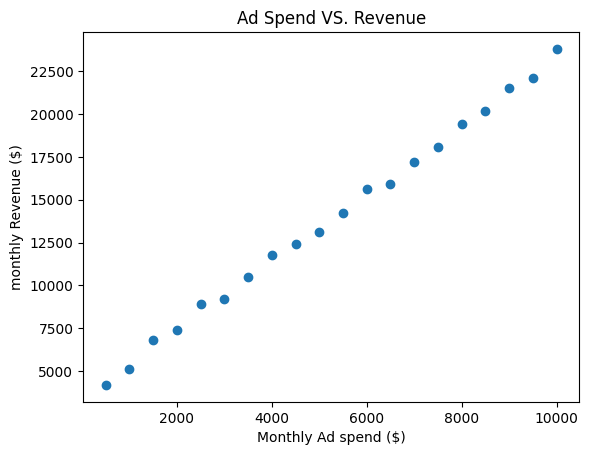

In [51]:
# scatter plot
plt.scatter(X2,y2)

# Labels and title
plt.xlabel('Monthly Ad spend ($)')
plt.ylabel('monthly Revenue ($)')
plt.title('Ad Spend VS. Revenue')

In another cell, copy and paste the code you used to generate a scatter plot. This
time, add a regression line overlayed on the scatter plot. Use a contrasting color and
add a legend distinguishing the data points from the regression line. Then run the cell
to display the plot.

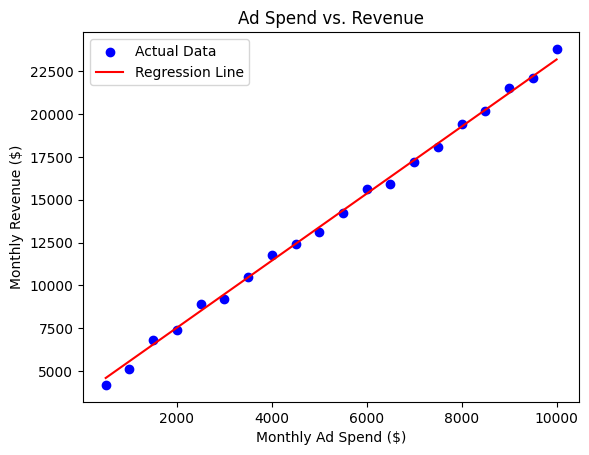

In [53]:
 # Scatter plot (actual data)
plt.scatter(X2, y2, color='blue', label='Actual Data')

# Regression line
plt.plot(X2, model2.predict(X2), color='red', label='Regression Line')

# Labels and title
plt.xlabel('Monthly Ad Spend ($)')

plt.ylabel('Monthly Revenue ($)')

plt.title('Ad Spend vs. Revenue')

# Legend
plt.legend()

plt.show()

Add a markdown cell and reflect: Does the regression line appear to fit the data well
visually? Does this match what the R² score told you?

 The red regression line appears to fit the data well visually because most of the data points are close to the line. this suggest a strong positive relationship
between monthly ad spend and monthly revenue.
This matches the R2 score because a high R2 value indicates that the model explains a large percentage of the variation in revenue
    Both the graph and R2 score shows that the regression line model is a good fit for the data